# Pneumonia Detection from Chest X-Rays

This notebook covers:
1. Data Loading & Augmentation
2. Building a simple CNN
3. Transfer Learning with ResNet18
4. Resumable training (checkpoints)
5. Explainability with Grad-CAM


## 1. Setup & Imports


In [10]:
!pip install torch torchvision gradio opencv-python matplotlib
# If you want to use the official pytorch-grad-cam library (highly recommended):
!pip install grad-cam
!pip install opencv-python



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Himanshu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Himanshu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Himanshu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [11]:
import sys
!{sys.executable} -m pip install opencv-python grad-cam torch torchvision matplotlib



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
import cv2
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


# Try to import pytorch-grad-cam
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    HAS_GRAD_CAM = True
except ImportError:
    HAS_GRAD_CAM = False
    print("Warning: pytorch-grad-cam not installed. We will try a manual approach or you can install it.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 2. Data Preparation

We resize to 224x224 as required by most standard transfer learning models (like ResNet). We also add basic augmentations.


In [13]:
data_dir = 'xray_dataset_covid19'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

# Transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Datasets
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)

class_names = train_data.classes
print("Classes:", class_names)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)


Classes: ['NORMAL', 'PNEUMONIA']


## 3. Model Definition

We provide two models: a Simple CNN and a Transfer Learning model (ResNet18).


In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

def get_resnet_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    num_ftrs = model.fc.in_features
    # Replace final layer for 2 classes
    model.fc = nn.Linear(num_ftrs, 2)
    return model


## 4. Resumable Training Loop

This function saves checkpoints after every epoch. If a checkpoint exists, it loads it and resumes training automatically.


In [15]:
def train_model_resumable(model, criterion, optimizer, num_epochs=10, checkpoint_path='checkpoint.pth'):
    start_epoch = 0
    
    # Check if checkpoint exists to resume
    if os.path.exists(checkpoint_path):
        print(f"Found checkpoint at {checkpoint_path}. Loading...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch + 1}...")
    else:
        print("Starting training from scratch...")

    model = model.to(device)
    
    for epoch in range(start_epoch, num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            
        epoch_loss = running_loss / len(train_data)
        epoch_acc = running_corrects.double() / len(train_data)
        
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                
        val_loss = val_loss / len(test_data)
        val_acc = val_corrects.double() / len(test_data)
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
        
        # Save Checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}\n")
        
    print('Training complete!')
    return model


### Start or Resume Training

To stop training at any time, just interrupt the cell. Run it again later, and it will pick up from the last completed epoch.


In [16]:
# Choose model: simple_cnn or resnet
MODEL_TYPE = 'resnet' # or 'simple_cnn'

if MODEL_TYPE == 'resnet':
    model = get_resnet_model()
    checkpoint_file = 'resnet_checkpoint.pth'
else:
    model = SimpleCNN()
    checkpoint_file = 'cnn_checkpoint.pth'

criterion = nn.CrossEntropyLoss()
# Standard learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set epochs. If it already trained 5/10 and you run this, it does 5 more.
# If you interrupt at 3/10, next time it resumes at 4/10.
model = train_model_resumable(model, criterion, optimizer, num_epochs=15, checkpoint_path=checkpoint_file)


Found checkpoint at resnet_checkpoint.pth. Loading...
Resuming training from epoch 16...
Training complete!


## 5. Explainability (Grad-CAM)

Visualizing what the model focuses on when predicting.


Prediction: PNEUMONIA (92.79% confidence)


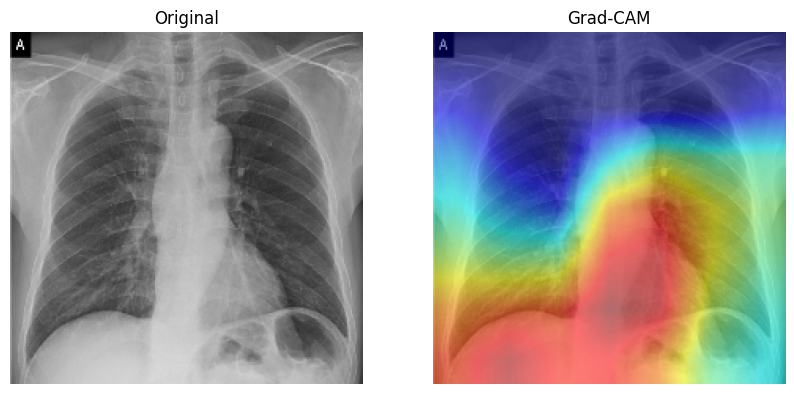

In [17]:
def get_gradcam_heatmap(image_tensor, model):
    if not HAS_GRAD_CAM:
        return np.zeros((224, 224, 3)) # Fallback if not installed
        
    # The target layer depends on the model. For ResNet18 it's layer4[-1]
    # For our simple CNN, it would be the last conv layer
    if isinstance(model, SimpleCNN):
        target_layers = [model.conv_layers[-2]]
    else:
        target_layers = [model.layer4[-1]]
        
    cam = GradCAM(model=model, target_layers=target_layers)
    
    # We pass the image to the cam generator
    grayscale_cam = cam(input_tensor=image_tensor)
    grayscale_cam = grayscale_cam[0, :]
    
    return grayscale_cam

def display_gradcam(image_path, model):
    model.eval()
    
    # Load raw image
    raw_img = cv2.imread(image_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = cv2.resize(raw_img, (224, 224))
    # Normalize 0-1 for visualization overlay
    float_img = np.float32(raw_img) / 255
    
    # Load transformed image for model
    img_pil = Image.open(image_path).convert('RGB')
    input_tensor = test_transforms(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(input_tensor)
        prob = torch.nn.functional.softmax(out, dim=1)[0]
        pred_class = torch.argmax(prob).item()
        confidence = prob[pred_class].item()
        
    print(f"Prediction: {class_names[pred_class]} ({confidence:.2%} confidence)")
    
    # Get heatmap
    if HAS_GRAD_CAM:
        heatmap = get_gradcam_heatmap(input_tensor, model)
        visualization = show_cam_on_image(float_img, heatmap, use_rgb=True)
        
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(raw_img)
        plt.title("Original")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title("Grad-CAM")
        plt.axis('off')
        plt.show()
    else:
        print("Please install grad-cam to see the heatmap visualizations.")
        plt.imshow(raw_img)
        plt.show()

# Test on a random image from the test set
sample_image = os.path.join(test_dir, 'PNEUMONIA', os.listdir(os.path.join(test_dir, 'PNEUMONIA'))[0])
display_gradcam(sample_image, model)
